# Univariate exploration of the hourly PV series

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pvforecast.config import PROCESSED_DIR, FIGURES_DIR

# Quality, gaps and aggregation are settled in 02 -> just load
df = pd.read_parquet(PROCESSED_DIR / "pv_hourly.parquet")
pv = df["pv_mwh"]

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Local time is derived for display/feature axes only
local = df.index.tz_convert("Europe/Berlin")

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
        "font.size": 11,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

print(f"Zeitraum: {df.index.min():%Y-%m-%d} bis {df.index.max():%Y-%m-%d}")
print(f"Stunden: {len(df):,}  |  Spalte: {df.columns.tolist()}")

Zeitraum: 2014-12-31 bis 2025-12-31
Stunden: 96,433  |  Spalte: ['pv_mwh']


## Target variable over time

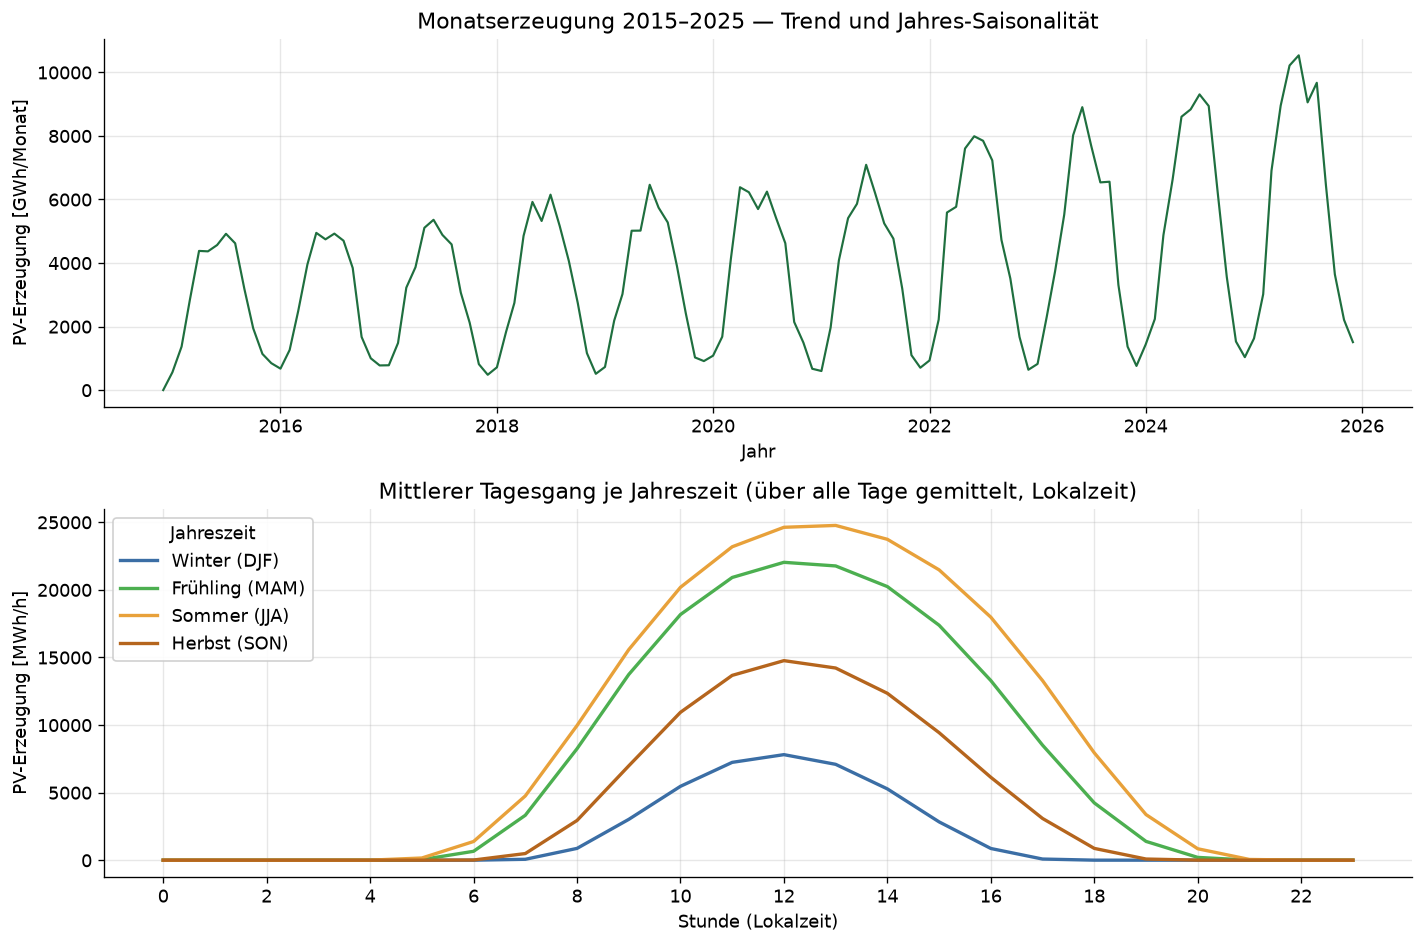

In [2]:
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(12, 8))

# (a) Monthly energy over all 11 years -> trend + annual seasonality
monthly = pv.resample("MS").sum() / 1e3  # MWh -> GWh
ax_top.plot(monthly.index, monthly.values, color="#1f6f3f", lw=1.3)
ax_top.set_title("Monatserzeugung 2015–2025 — Trend und Jahres-Saisonalität")
ax_top.set_ylabel("PV-Erzeugung [GWh/Monat]")
ax_top.set_xlabel("Jahr")

# (b) Mean daily cycle per meteorological season -> robust day-shape
season = local.month % 12 // 3  # 0=Winter, 1=Frühling, 2=Sommer, 3=Herbst
season_names = ["Winter (DJF)", "Frühling (MAM)", "Sommer (JJA)", "Herbst (SON)"]
season_colors = ["#3b6ea5", "#4caf50", "#e8a13a", "#b5651d"]
prof = pd.DataFrame({"pv": pv.values, "hour": local.hour, "season": season})
for s in range(4):
    m = prof[prof.season == s].groupby("hour")["pv"].mean()
    ax_bot.plot(m.index, m.values, label=season_names[s], color=season_colors[s], lw=2)
ax_bot.set_title(
    "Mittlerer Tagesgang je Jahreszeit (über alle Tage gemittelt, Lokalzeit)"
)
ax_bot.set_ylabel("PV-Erzeugung [MWh/h]")
ax_bot.set_xlabel("Stunde (Lokalzeit)")
ax_bot.set_xticks(range(0, 24, 2))
ax_bot.legend(title="Jahreszeit", loc="upper left", framealpha=0.9)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_zielgroesse_zeit.png")
plt.show()

## Annual generation and hourly peak

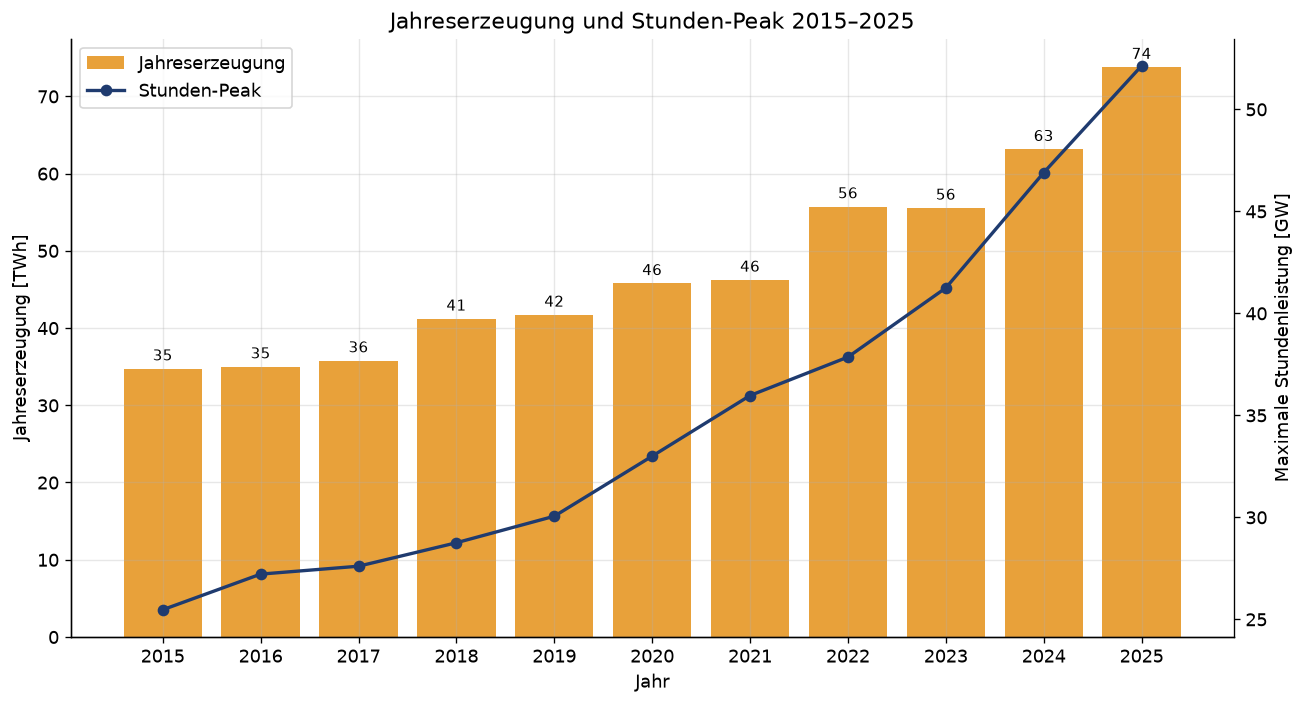

In [3]:
year = local.year
# keep full years only
gen_twh = (pv.groupby(year).sum() / 1e6).loc[2015:2025]  # MWh -> TWh
peak_gw = (pv.groupby(year).max() / 1e3).loc[2015:2025]  # MWh/h -> GW

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(gen_twh.index, gen_twh.values, color="#e8a13a", label="Jahreserzeugung")
ax.set_ylabel("Jahreserzeugung [TWh]")
ax.set_xlabel("Jahr")
ax.set_title("Jahreserzeugung und Stunden-Peak 2015–2025")
ax.set_xticks(gen_twh.index)
for x, v in gen_twh.items():
    ax.text(x, v + 0.6, f"{v:.0f}", ha="center", va="bottom", fontsize=9)

# year's highest hourly feed-in
ax2 = ax.twinx()
ax2.spines["right"].set_visible(True)
ax2.grid(False)
ax2.plot(
    peak_gw.index,
    peak_gw.values,
    color="#1f3b6f",
    marker="o",
    lw=2,
    label="Stunden-Peak",
)
ax2.set_ylabel("Maximale Stundenleistung [GW]")

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_jahreserzeugung_peak.png")
plt.show()

## Heatmap: Hour × Month

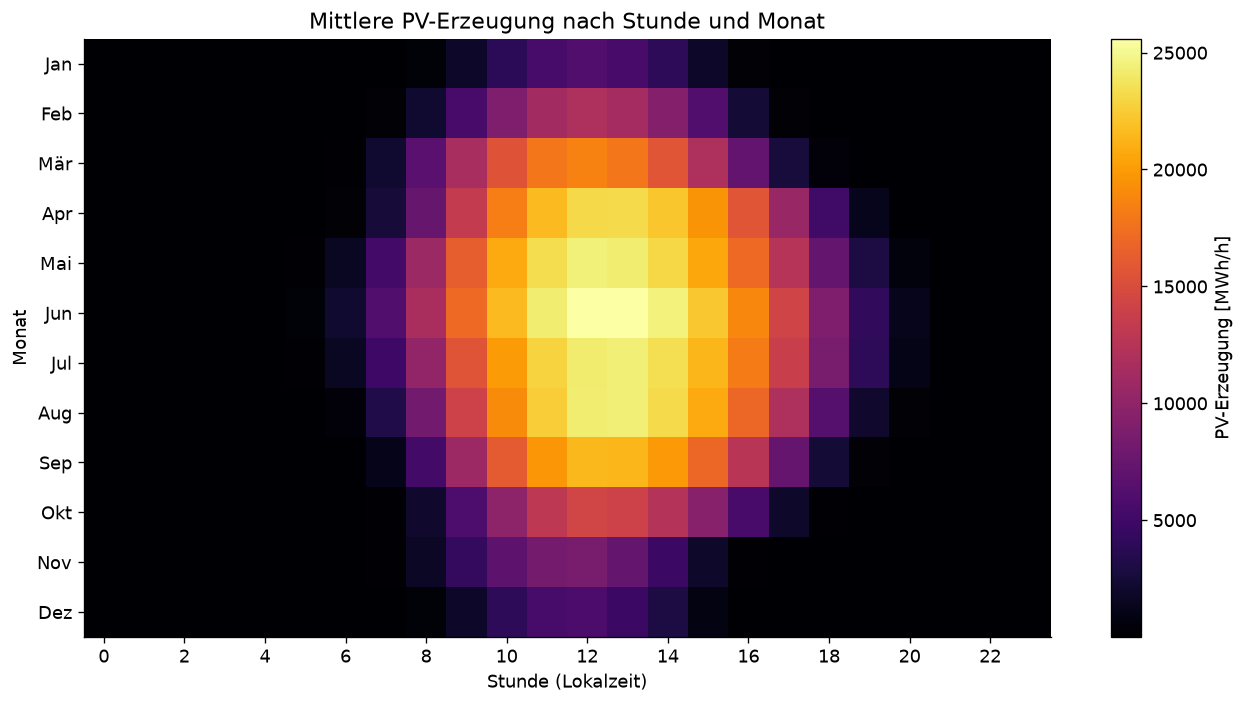

In [4]:
hm = pd.DataFrame({"pv": pv.values, "hour": local.hour, "month": local.month})
grid = hm.groupby(["month", "hour"])["pv"].mean().unstack("hour")

fig, ax = plt.subplots(figsize=(11, 6))
mesh = ax.pcolormesh(
    grid.columns, grid.index, grid.values, cmap="inferno", shading="nearest"
)
ax.set_title("Mittlere PV-Erzeugung nach Stunde und Monat")
ax.set_xlabel("Stunde (Lokalzeit)")
ax.set_ylabel("Monat")
ax.set_xticks(range(0, 24, 2))
ax.set_yticks(range(1, 13))
ax.set_yticklabels(
    ["Jan", "Feb", "Mär", "Apr", "Mai", "Jun", "Jul", "Aug", "Sep", "Okt", "Nov", "Dez"]
)
ax.invert_yaxis()
ax.grid(False)
cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label("PV-Erzeugung [MWh/h]")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_heatmap_stunde_monat.png")
plt.show()

## Distribution of values

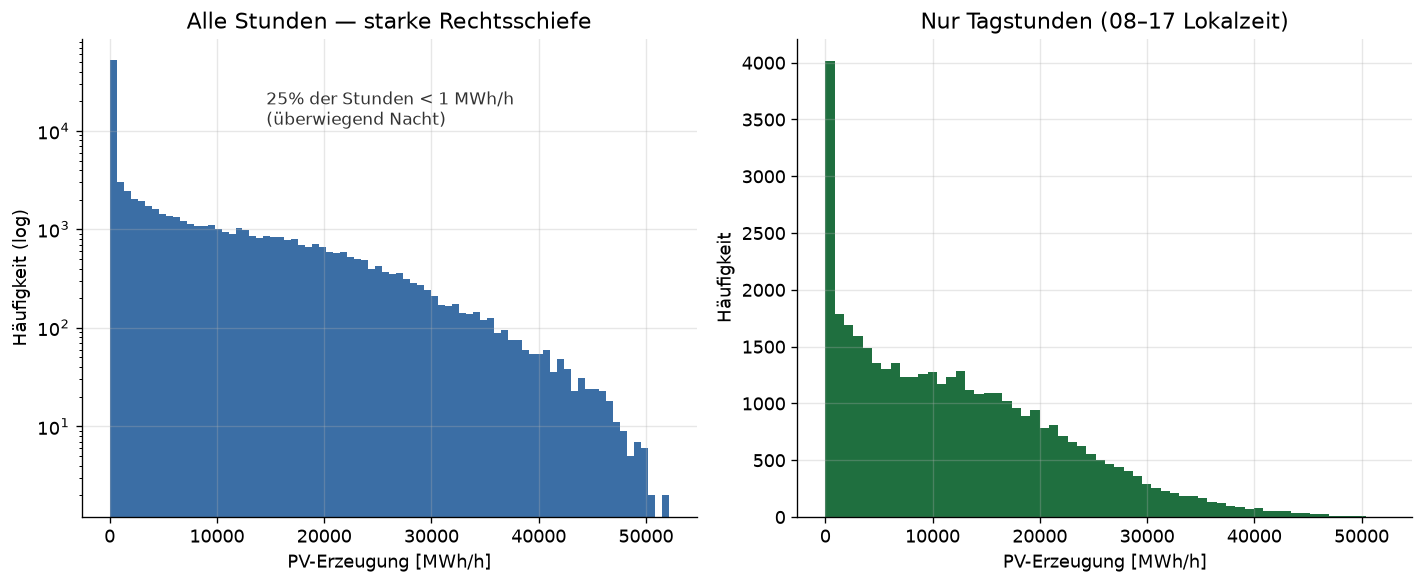

In [5]:
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 5))

# All hours: strong right skew
ax_l.hist(pv.values, bins=80, color="#3b6ea5")
ax_l.set_yscale("log")
ax_l.set_title("Alle Stunden — starke Rechtsschiefe")
ax_l.set_xlabel("PV-Erzeugung [MWh/h]")
ax_l.set_ylabel("Häufigkeit (log)")
near_zero = float((pv < 1).mean())
ax_l.annotate(
    f"{near_zero:.0%} der Stunden < 1 MWh/h\n(überwiegend Nacht)",
    xy=(0.30, 0.82),
    xycoords="axes fraction",
    ha="left",
    fontsize=10,
    color="#333",
)

day_mask = (local.hour >= 8) & (local.hour <= 17)
ax_r.hist(pv.values[day_mask], bins=60, color="#1f6f3f")
ax_r.set_title("Nur Tagstunden (08–17 Lokalzeit)")
ax_r.set_xlabel("PV-Erzeugung [MWh/h]")
ax_r.set_ylabel("Häufigkeit")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_verteilung.png")
plt.show()